# Dixon–Coles-only feature selection across five leagues

This development notebook repeats the feature-group and floating-refinement process used by the removal-of-data comparison notebooks, but only for Dixon–Coles with player adjustments. Every candidate is fitted **separately inside each league**. The notebook never creates one shared five-league team-strength system.

Candidates are compared with plain Dixon–Coles on identical league/fold matches. The primary score is the equal-league mean change in log loss: negative is better

In [1]:
from __future__ import annotations

import sys
from collections import OrderedDict
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'multi_league_research').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the repository')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
RESEARCH_DIR = REPO_ROOT / 'multi_league_research'
if str(RESEARCH_DIR) not in sys.path:
    sys.path.insert(0, str(RESEARCH_DIR))

from build_match_features import (
    ADJUSTED_MEAN_FEATURES, BASE_SUM_FEATURES, DISTRIBUTION_FEATURES,
    LINEUP_FEATURES, POSITION_FEATURES, RECENCY_MEAN_FEATURES,
    TEAM_STRENGTH_FEATURES,
)
from constants import DEVELOPMENT_FOLDS, EXPECTED_LEAGUES
from data.load_model_dataset import load_dataset
from evaluation.metrics import score_predictions
from evaluation.walk_forward import select_development_leagues, validate_development_dataset, validate_fold
from models.dixon_coles import DixonColesModel
from models.dixon_coles_player_form import DixonColesPlayerFormModel

In [2]:
MODEL_DATASET = REPO_ROOT / 'data' / 'processed' / 'all_leagues' / 'development_model_dataset.csv'
OUTPUT_ROOT = RESEARCH_DIR / 'visuals' / 'dixon_coles_feature_selection'
OUTPUT_DIR = OUTPUT_ROOT / 'tables'
IMAGE_DIR = OUTPUT_ROOT / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# Match the more thorough removal-of-data run
REFINEMENT_SEEDS = 2
MAX_FLOATING_STEPS = 6
SELECTION_TOLERANCE = 0.005
MIN_REFINEMENT_IMPROVEMENT = 0.0005
MAX_ACCEPTABLE_LEAGUE_HARM = 0.01

MODEL_DATASET, OUTPUT_DIR, IMAGE_DIR

(WindowsPath('C:/Users/skous/Super-League-odds-research/data/processed/all_leagues/development_model_dataset.csv'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/multi_league_research/visuals/dixon_coles_feature_selection/tables'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/multi_league_research/visuals/dixon_coles_feature_selection/figures'))

## Candidate feature groups

The groups are identical to the other removal-of-data notebooks. The exhaustive first phase evaluates all 63 nonempty group combinations.

In [3]:
def unique(values: list[str]) -> list[str]:
    return list(dict.fromkeys(values))

FEATURE_GROUPS = OrderedDict([
    ('legacy_player_form', unique([*BASE_SUM_FEATURES, 'rating_mean_5', 'starters_without_history', 'starters_without_full_window'])),
    ('team_strength', list(TEAM_STRENGTH_FEATURES)),
    ('opponent_adjusted_form', list(ADJUSTED_MEAN_FEATURES)),
    ('lineup_continuity', list(LINEUP_FEATURES)),
    ('position_and_distribution', unique(POSITION_FEATURES + DISTRIBUTION_FEATURES)),
    ('recency', list(RECENCY_MEAN_FEATURES)),
])

CANDIDATE_FEATURE_SETS = OrderedDict()
CANDIDATE_GROUPS = {}
group_names = list(FEATURE_GROUPS)
for group_count in range(1, len(group_names) + 1):
    for selected_groups in combinations(group_names, group_count):
        name = ' + '.join(selected_groups)
        CANDIDATE_FEATURE_SETS[name] = unique([feature for group in selected_groups for feature in FEATURE_GROUPS[group]])
        CANDIDATE_GROUPS[name] = selected_groups

ALL_BASE_FEATURES = unique([feature for features in FEATURE_GROUPS.values() for feature in features])
pd.DataFrame([{'group': name, 'features': len(features)} for name, features in FEATURE_GROUPS.items()])

,group,features
0,legacy_player_form,7
1,team_strength,8
2,opponent_adjusted_form,24
3,lineup_continuity,7
4,position_and_distribution,20
5,recency,17


## Five-league chronological sample and plain Dixon–Coles baseline

Each fold is split by league before fitting. Plain Dixon–Coles is fitted once per league/fold and reused as the fixed baseline for every candidate.

In [4]:
dataset = load_dataset(MODEL_DATASET)
dataset = select_development_leagues(dataset)
validate_development_dataset(dataset)

def league_development_folds(frame: pd.DataFrame):
    for validation_season, train_seasons in DEVELOPMENT_FOLDS:
        train_all = frame[frame['season'].isin(train_seasons)].copy()
        validation_all = frame[frame['season'].eq(validation_season)].copy()
        validate_fold(train_all, validation_all, validation_season, train_seasons)
        for league in sorted(EXPECTED_LEAGUES):
            train = train_all[train_all['league'].eq(league)].copy()
            validation = validation_all[validation_all['league'].eq(league)].copy()
            if train.empty or validation.empty:
                raise ValueError(f'{league}/{validation_season} has an empty train or validation set')
            yield league, validation_season, train_seasons, train, validation

def checked_probabilities(model, train: pd.DataFrame, validation: pd.DataFrame) -> np.ndarray:
    model.fit(train)
    probabilities = model.predict_proba(validation)
    if probabilities.shape != (len(validation), 3):
        raise ValueError('Unexpected probability shape')
    if not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-10):
        raise ValueError('Probabilities do not sum to one')
    return probabilities

baseline_rows = []
for league, season, train_seasons, train, validation in league_development_folds(dataset):
    probabilities = checked_probabilities(DixonColesModel(), train, validation)
    baseline_rows.append({
        'league': league, 'validation_season': season,
        'train_seasons': ';'.join(train_seasons), 'train_matches': len(train),
        'validation_matches': len(validation),
        **{f'baseline_{key}': value for key, value in score_predictions(validation['result_3way'], probabilities).items()},
    })
baseline_folds = pd.DataFrame(baseline_rows)
baseline_folds.to_csv(OUTPUT_DIR / 'plain_dixon_coles_baseline.csv', index=False)
baseline_folds

C:\Users\skous\Super-League-odds-research\multi_league_research\data\load_model_dataset.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["_match_datetime"] = pd.to_datetime(
C:\Users\skous\Super-League-odds-research\multi_league_research\data\load_model_dataset.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["market_log_home_vs_draw"] = np.log(
C:\Users\skous\Super-League-odds-research\multi_league_research\data\load_model_dataset.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually th

,league,validation_season,train_seasons,train_matches,validation_matches,baseline_log_loss,baseline_brier_score,baseline_accuracy
0,belgium,2022-23,2020-21;2021-22,569,304,0.975810,0.578599,0.523026
1,netherlands,2022-23,2020-21;2021-22,562,288,0.942431,0.559175,0.576389
2,portugal,2022-23,2020-21;2021-22,477,240,0.926413,0.541325,0.545833
3,scotland,2022-23,2020-21;2021-22,456,226,0.892251,0.520911,0.615044
4,turkey,2022-23,2020-21;2021-22,679,277,1.010901,0.604023,0.519856
5,belgium,2023-24,2020-21;2021-22;2022-23,873,312,1.001390,0.596898,0.512821
6,netherlands,2023-24,2020-21;2021-22;2022-23,850,306,0.936246,0.555852,0.562092
7,portugal,2023-24,2020-21;2021-22;2022-23,717,64,0.850473,0.490999,0.656250
8,scotland,2023-24,2020-21;2021-22;2022-23,682,212,0.947089,0.559957,0.547170
9,turkey,2023-24,2020-21;2021-22;2022-23,956,339,0.987750,0.586688,0.513274


## Candidate evaluation

The checkpoint is updated after every new feature combination because this search is expensive. Restarting the notebook reuses completed combinations. Within each league, fold losses are weighted by their number of matches; the final score then gives every league equal weight.

In [5]:
CHECKPOINT_PATH = OUTPUT_DIR / 'candidate_league_folds_checkpoint.csv'
checkpoint = pd.read_csv(CHECKPOINT_PATH) if CHECKPOINT_PATH.exists() else pd.DataFrame()
evaluation_cache = {signature: group.copy() for signature, group in checkpoint.groupby('feature_signature', sort=False)} if not checkpoint.empty else {}

def feature_signature(features: list[str]) -> str:
    return '|'.join(sorted(features))

def summarize_candidate(folds: pd.DataFrame, feature_set: str, features: list[str]) -> dict[str, object]:
    league_rows = []
    for league, group in folds.groupby('league', sort=True):
        weights = group['validation_matches'] / group['validation_matches'].sum()
        candidate_loss = float(np.dot(weights, group['log_loss']))
        baseline_loss = float(np.dot(weights, group['baseline_log_loss']))
        candidate_brier = float(np.dot(weights, group['brier_score']))
        baseline_brier = float(np.dot(weights, group['baseline_brier_score']))
        league_rows.append({
            'league': league, 'log_loss': candidate_loss, 'baseline_log_loss': baseline_loss,
            'log_loss_delta': candidate_loss - baseline_loss,
            'brier_score': candidate_brier, 'baseline_brier_score': baseline_brier,
            'brier_delta': candidate_brier - baseline_brier,
        })
    leagues = pd.DataFrame(league_rows)
    return {
        'model': 'dixon_coles_player_form', 'feature_set': feature_set,
        'feature_signature': feature_signature(features), 'base_feature_count': len(features),
        'equal_league_log_loss': float(leagues['log_loss'].mean()),
        'equal_league_baseline_log_loss': float(leagues['baseline_log_loss'].mean()),
        'equal_league_log_loss_delta': float(leagues['log_loss_delta'].mean()),
        'equal_league_brier_delta': float(leagues['brier_delta'].mean()),
        'leagues_improved': int(leagues['log_loss_delta'].lt(0).sum()),
        'worst_league_log_loss_delta': float(leagues['log_loss_delta'].max()),
        'league_delta_std': float(leagues['log_loss_delta'].std(ddof=0)),
        'fold_league_delta_std': float(folds['log_loss_delta'].std(ddof=0)),
    }

def evaluate_feature_set(feature_set: str, features: list[str]) -> tuple[pd.DataFrame, dict[str, object]]:
    global checkpoint
    signature = feature_signature(features)
    if signature in evaluation_cache:
        folds = evaluation_cache[signature].copy()
        folds['feature_set'] = feature_set
        return folds, summarize_candidate(folds, feature_set, features)

    columns = [f'diff_{feature}' for feature in features]
    missing = sorted(set(columns).difference(dataset.columns))
    if missing:
        raise ValueError(f'{feature_set} is missing columns: {missing[:10]}')

    rows = []
    baseline_lookup = baseline_folds.set_index(['league', 'validation_season'])
    for league, season, train_seasons, train, validation in league_development_folds(dataset):
        model = DixonColesPlayerFormModel(player_features=columns, name='dixon_coles_player_form')
        probabilities = checked_probabilities(model, train, validation)
        scores = score_predictions(validation['result_3way'], probabilities)
        baseline = baseline_lookup.loc[(league, season)]
        rows.append({
            'feature_signature': signature, 'feature_set': feature_set,
            'league': league, 'validation_season': season,
            'train_seasons': ';'.join(train_seasons), 'train_matches': len(train),
            'validation_matches': len(validation), 'base_feature_count': len(features),
            **scores,
            'baseline_log_loss': baseline['baseline_log_loss'],
            'baseline_brier_score': baseline['baseline_brier_score'],
            'log_loss_delta': scores['log_loss'] - baseline['baseline_log_loss'],
            'brier_delta': scores['brier_score'] - baseline['baseline_brier_score'],
        })
    folds = pd.DataFrame(rows)
    evaluation_cache[signature] = folds.copy()
    checkpoint = pd.concat(list(evaluation_cache.values()), ignore_index=True)
    checkpoint.to_csv(CHECKPOINT_PATH, index=False)
    return folds, summarize_candidate(folds, feature_set, features)

## Phase A: exhaustive feature-group combinations

In [6]:
group_fold_frames = []
group_summary_rows = []
for name, features in CANDIDATE_FEATURE_SETS.items():
    folds, summary = evaluate_feature_set(name, features)
    selected_groups = '|'.join(CANDIDATE_GROUPS[name])
    folds['selected_groups'] = selected_groups
    summary['selected_groups'] = selected_groups
    summary['group_count'] = len(CANDIDATE_GROUPS[name])
    group_fold_frames.append(folds)
    group_summary_rows.append(summary)

group_folds = pd.concat(group_fold_frames, ignore_index=True)
group_summary = pd.DataFrame(group_summary_rows).sort_values(['equal_league_log_loss_delta', 'base_feature_count'], kind='stable')
group_folds.to_csv(OUTPUT_DIR / 'feature_group_combination_league_folds.csv', index=False)
group_summary.to_csv(OUTPUT_DIR / 'feature_group_combination_summary.csv', index=False)
group_summary.head(15)

,model,feature_set,feature_signature,base_feature_count,equal_league_log_loss,equal_league_baseline_log_loss,equal_league_log_loss_delta,equal_league_brier_delta,leagues_improved,worst_league_log_loss_delta,league_delta_std,fold_league_delta_std,selected_groups,group_count
3,dixon_coles_player_form,lineup_continuity,mean_pairwise_prior_minutes|mean_pairwise_prio...,7,0.961080,0.962081,-0.001001,-0.001132,3,0.002646,0.003227,0.006155,lineup_continuity,1
0,dixon_coles_player_form,legacy_player_form,defensive_actions_per90_sum_5|key_passes_per90...,7,0.964368,0.962081,0.002286,0.000440,2,0.010045,0.005297,0.012859,legacy_player_form,1
8,dixon_coles_player_form,legacy_player_form + lineup_continuity,defensive_actions_per90_sum_5|key_passes_per90...,14,0.966355,0.962081,0.004274,0.001162,2,0.016886,0.008638,0.018004,legacy_player_form|lineup_continuity,2
5,dixon_coles_player_form,recency,defensive_actions_per90_lineup_mean_1|defensiv...,17,0.972487,0.962081,0.010405,0.005719,0,0.020103,0.006600,0.013350,recency,1
19,dixon_coles_player_form,lineup_continuity + recency,defensive_actions_per90_lineup_mean_1|defensiv...,24,0.972851,0.962081,0.010770,0.005259,1,0.025557,0.009610,0.018701,lineup_continuity|recency,2
10,dixon_coles_player_form,legacy_player_form + recency,defensive_actions_per90_lineup_mean_1|defensiv...,24,0.973634,0.962081,0.011552,0.006221,0,0.021221,0.007532,0.014728,legacy_player_form|recency,2
4,dixon_coles_player_form,position_and_distribution,adjusted_defensive_actions_lineup_std_across_s...,20,0.974583,0.962081,0.012501,0.007786,0,0.026610,0.007760,0.017302,position_and_distribution,1
18,dixon_coles_player_form,lineup_continuity + position_and_distribution,adjusted_defensive_actions_lineup_std_across_s...,27,0.974984,0.962081,0.012903,0.006887,0,0.030438,0.009679,0.019954,lineup_continuity|position_and_distribution,2
2,dixon_coles_player_form,opponent_adjusted_form,adjusted_defensive_actions_lineup_mean_1|adjus...,24,0.976396,0.962081,0.014315,0.008513,0,0.020145,0.006185,0.015486,opponent_adjusted_form,1
29,dixon_coles_player_form,legacy_player_form + lineup_continuity + recency,defensive_actions_per90_lineup_mean_1|defensiv...,31,0.976563,0.962081,0.014482,0.007620,0,0.030814,0.010837,0.022057,legacy_player_form|lineup_continuity|recency,3


## Phase B: two-start, six-step floating refinement

At each step, every one-feature addition and removal is tested. A move is accepted only when it improves equal-league log loss by at least the declared minimum.

In [7]:
refinement_candidate_rows = []
refinement_history_rows = []
refined_finalists = []

def floating_refine(seed_name: str, seed_features: list[str], seed_rank: int):
    current = list(seed_features)
    _, current_summary = evaluate_feature_set(f'seed_{seed_rank}', current)
    refinement_history_rows.append({'seed': seed_name, 'step': 0, 'action': 'seed', 'feature': '', 'feature_count': len(current), **current_summary})
    for step in range(1, MAX_FLOATING_STEPS + 1):
        moves = []
        current_set = set(current)
        for action, candidates in (
            ('remove', list(current) if len(current) > 1 else []),
            ('add', [feature for feature in ALL_BASE_FEATURES if feature not in current_set]),
        ):
            for feature in candidates:
                trial = [value for value in current if value != feature] if action == 'remove' else unique(current + [feature])
                trial_name = f'floating_s{seed_rank}_t{step}_{action}_{feature}'
                _, summary = evaluate_feature_set(trial_name, trial)
                moves.append((summary['equal_league_log_loss_delta'], len(trial), action, feature, trial, summary))
        if not moves:
            break
        moves.sort(key=lambda move: move[:4])
        best_delta, _, best_action, best_feature, best_trial, best_summary = moves[0]
        accepted = best_delta < current_summary['equal_league_log_loss_delta'] - MIN_REFINEMENT_IMPROVEMENT
        for delta, count, action, feature, trial, summary in moves:
            refinement_candidate_rows.append({
                'seed': seed_name, 'step': step, 'action': action, 'feature': feature,
                'feature_count': count, 'equal_league_log_loss_delta': delta,
                'leagues_improved': summary['leagues_improved'],
                'worst_league_log_loss_delta': summary['worst_league_log_loss_delta'],
                'accepted': bool(accepted and action == best_action and feature == best_feature),
            })
        pd.DataFrame(refinement_candidate_rows).to_csv(OUTPUT_DIR / 'floating_refinement_candidates_checkpoint.csv', index=False)
        if not accepted:
            break
        current, current_summary = best_trial, best_summary
        refinement_history_rows.append({'seed': seed_name, 'step': step, 'action': best_action, 'feature': best_feature, 'feature_count': len(current), **current_summary})
        pd.DataFrame(refinement_history_rows).to_csv(OUTPUT_DIR / 'floating_refinement_history_checkpoint.csv', index=False)
    return current, current_summary

best_group_delta = group_summary['equal_league_log_loss_delta'].min()
near_best_groups = group_summary[group_summary['equal_league_log_loss_delta'].le(best_group_delta + SELECTION_TOLERANCE)].copy()
parsimonious_seed = near_best_groups.sort_values(['base_feature_count', 'equal_league_log_loss_delta', 'worst_league_log_loss_delta'], kind='stable').iloc[0]['feature_set']
ranked_seeds = group_summary['feature_set'].tolist()
seed_names = unique([parsimonious_seed, *ranked_seeds])[:REFINEMENT_SEEDS]

for seed_rank, seed_name in enumerate(seed_names, start=1):
    features, summary = floating_refine(seed_name, CANDIDATE_FEATURE_SETS[seed_name], seed_rank)
    refined_finalists.append({**summary, 'seed_feature_set': seed_name, 'features': features, 'selection_source': 'floating_refinement'})

refinement_candidates = pd.DataFrame(refinement_candidate_rows)
refinement_history = pd.DataFrame(refinement_history_rows)
refined_finalists_frame = pd.DataFrame([{**row, 'features': '|'.join(row['features'])} for row in refined_finalists])
refinement_candidates.to_csv(OUTPUT_DIR / 'floating_refinement_candidates.csv', index=False)
refinement_history.to_csv(OUTPUT_DIR / 'floating_refinement_history.csv', index=False)
refined_finalists_frame.to_csv(OUTPUT_DIR / 'floating_refinement_finalists.csv', index=False)
refined_finalists_frame

,model,feature_set,feature_signature,base_feature_count,equal_league_log_loss,equal_league_baseline_log_loss,equal_league_log_loss_delta,equal_league_brier_delta,leagues_improved,worst_league_log_loss_delta,league_delta_std,fold_league_delta_std,seed_feature_set,features,selection_source
0,dixon_coles_player_form,floating_s1_t4_remove_replacement_quality,key_passes_per90_lineup_mean_3|mean_pairwise_p...,5,0.956039,0.962081,-0.006042,-0.004556,3,0.002159,0.007444,0.011338,lineup_continuity,missing_regular_starters|mean_pairwise_prior_s...,floating_refinement
1,dixon_coles_player_form,floating_s2_t5_remove_starters_without_full_wi...,key_passes_per90_sum_5|missing_regular_starter...,4,0.957505,0.962081,-0.004576,-0.003878,5,-0.000839,0.003918,0.008221,legacy_player_form,key_passes_per90_sum_5|recent_minutes_sum_5|st...,floating_refinement


## Select one shared feature list

The candidates include plain Dixon–Coles with zero player features. Therefore the notebook can conclude that no player adjustment is justified. Among candidates within the tolerance of the best average result, preference is given to candidates without a large loss in any league, then to broader league improvement, fewer features, and the better average result.

In [8]:
group_seed_name = near_best_groups.sort_values(['base_feature_count', 'equal_league_log_loss_delta'], kind='stable').iloc[0]['feature_set']
group_features = CANDIDATE_FEATURE_SETS[group_seed_name]
_, group_candidate = evaluate_feature_set('group_search_finalist', group_features)
selection_candidates = [{**group_candidate, 'features': group_features, 'selection_source': 'group_search'}]
selection_candidates.extend(refined_finalists)
selection_candidates.append({
    'model': 'dixon_coles', 'feature_set': 'plain_dixon_coles', 'feature_signature': '',
    'base_feature_count': 0,
    'equal_league_log_loss': float(baseline_folds.groupby('league').apply(lambda group: np.average(group['baseline_log_loss'], weights=group['validation_matches']), include_groups=False).mean()),
    'equal_league_baseline_log_loss': float(baseline_folds.groupby('league').apply(lambda group: np.average(group['baseline_log_loss'], weights=group['validation_matches']), include_groups=False).mean()),
    'equal_league_log_loss_delta': 0.0, 'equal_league_brier_delta': 0.0,
    'leagues_improved': 0, 'worst_league_log_loss_delta': 0.0,
    'league_delta_std': 0.0, 'fold_league_delta_std': 0.0,
    'features': [], 'selection_source': 'plain_baseline',
})

best_delta = min(candidate['equal_league_log_loss_delta'] for candidate in selection_candidates)
near_best = [candidate for candidate in selection_candidates if candidate['equal_league_log_loss_delta'] <= best_delta + SELECTION_TOLERANCE]
safe = [candidate for candidate in near_best if candidate['worst_league_log_loss_delta'] <= MAX_ACCEPTABLE_LEAGUE_HARM]
eligible = safe if safe else near_best
selected = sorted(eligible, key=lambda candidate: (-candidate['leagues_improved'], len(candidate['features']), candidate['equal_league_log_loss_delta'], candidate['worst_league_log_loss_delta']))[0]
selected_features = list(selected['features'])

selected_feature_set = pd.DataFrame([{**selected, 'features': '|'.join(selected_features), 'best_observed_delta': best_delta, 'selection_tolerance': SELECTION_TOLERANCE, 'max_acceptable_league_harm': MAX_ACCEPTABLE_LEAGUE_HARM}])
selected_features_table = pd.DataFrame([{'model': 'dixon_coles_player_form', 'feature': feature} for feature in selected_features], columns=['model', 'feature'])
selected_feature_set.to_csv(OUTPUT_DIR / 'selected_feature_set.csv', index=False)
selected_features_table.to_csv(OUTPUT_DIR / 'selected_features.csv', index=False)
selected_feature_set

,model,feature_set,feature_signature,base_feature_count,equal_league_log_loss,equal_league_baseline_log_loss,equal_league_log_loss_delta,equal_league_brier_delta,leagues_improved,worst_league_log_loss_delta,league_delta_std,fold_league_delta_std,seed_feature_set,features,selection_source,best_observed_delta,selection_tolerance,max_acceptable_league_harm
0,dixon_coles_player_form,floating_s2_t5_remove_starters_without_full_wi...,key_passes_per90_sum_5|missing_regular_starter...,4,0.957505,0.962081,-0.004576,-0.003878,5,-0.000839,0.003918,0.008221,legacy_player_form,key_passes_per90_sum_5|recent_minutes_sum_5|st...,floating_refinement,-0.006042,0.005,0.01


## Final diagnostics and figures

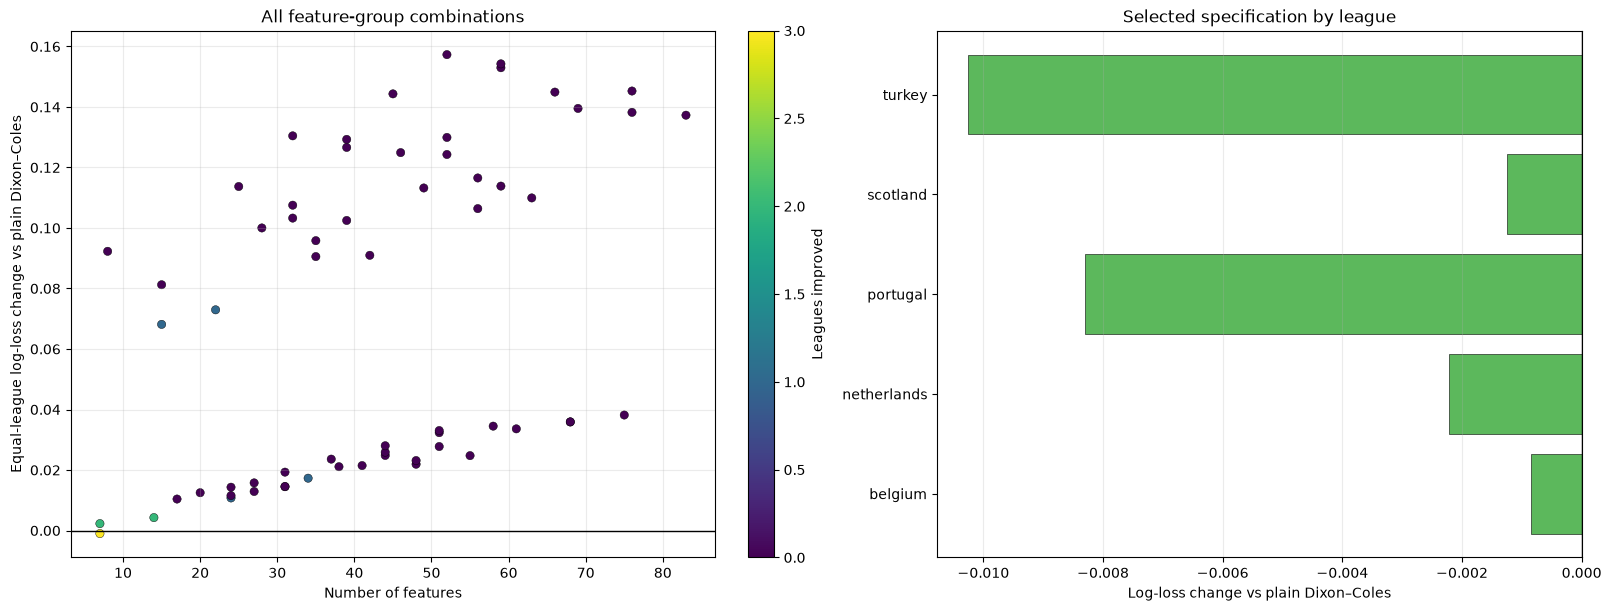

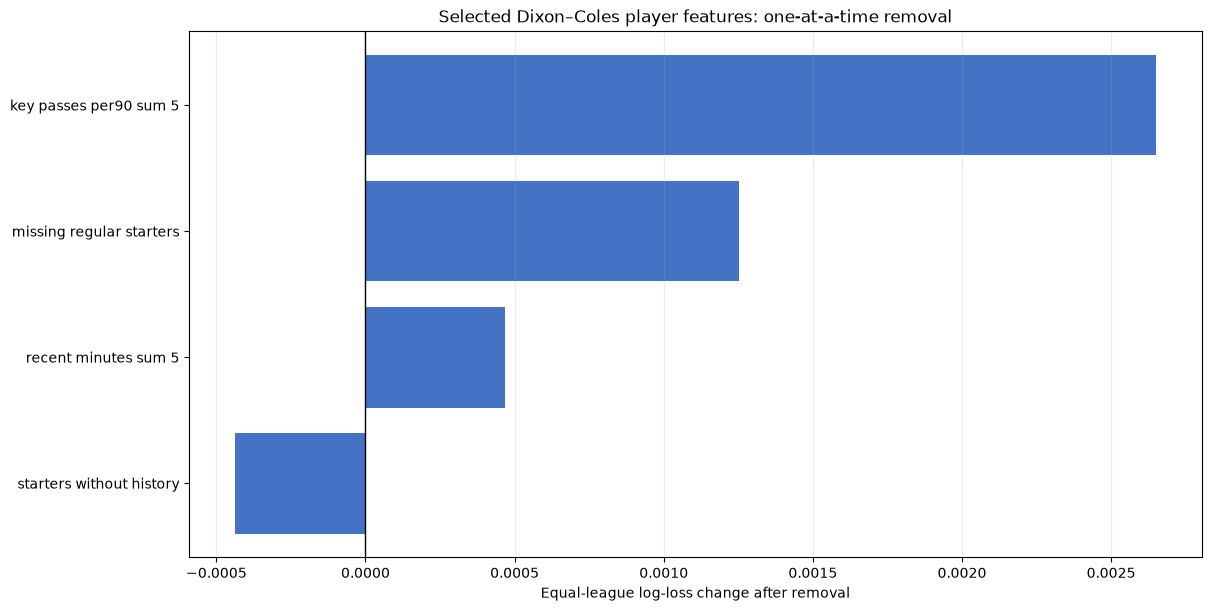

Saved tables to C:\Users\skous\Super-League-odds-research\multi_league_research\visuals\dixon_coles_feature_selection\tables
Saved figures to C:\Users\skous\Super-League-odds-research\multi_league_research\visuals\dixon_coles_feature_selection\figures
Selected 4 player features


In [9]:
if selected_features:
    selected_folds, selected_summary = evaluate_feature_set('selected_full', selected_features)
    league_effects = []
    for league, group in selected_folds.groupby('league', sort=True):
        weights = group['validation_matches'] / group['validation_matches'].sum()
        league_effects.append({'league': league, 'log_loss_delta': float(np.dot(weights, group['log_loss_delta'])), 'brier_delta': float(np.dot(weights, group['brier_delta']))})
    league_effects = pd.DataFrame(league_effects)
    removal_rows = []
    for feature in selected_features:
        remaining = [value for value in selected_features if value != feature]
        if not remaining:
            continue
        _, summary = evaluate_feature_set(f'without_{feature}', remaining)
        removal_rows.append({**summary, 'removed_feature': feature, 'delta_change_from_selected': summary['equal_league_log_loss_delta'] - selected_summary['equal_league_log_loss_delta']})
    individual_removals = pd.DataFrame(removal_rows)
else:
    league_effects = pd.DataFrame({'league': sorted(EXPECTED_LEAGUES), 'log_loss_delta': 0.0, 'brier_delta': 0.0})
    individual_removals = pd.DataFrame(columns=['removed_feature', 'delta_change_from_selected'])

league_effects.to_csv(OUTPUT_DIR / 'selected_feature_league_effects.csv', index=False)
individual_removals.to_csv(OUTPUT_DIR / 'individual_feature_removal_summary.csv', index=False)

plt.style.use('default')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white'})
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
scatter = axes[0].scatter(group_summary['base_feature_count'], group_summary['equal_league_log_loss_delta'], c=group_summary['leagues_improved'], cmap='viridis', edgecolor='black', linewidth=0.3)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set(title='All feature-group combinations', xlabel='Number of features', ylabel='Equal-league log-loss change vs plain Dixon–Coles')
axes[0].grid(alpha=0.25)
fig.colorbar(scatter, ax=axes[0], label='Leagues improved')
colors = ['#5CB85C' if value < 0 else '#D9534F' if value > 0 else '#4472C4' for value in league_effects['log_loss_delta']]
axes[1].barh(league_effects['league'], league_effects['log_loss_delta'], color=colors, edgecolor='black', linewidth=0.4)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set(title='Selected specification by league', xlabel='Log-loss change vs plain Dixon–Coles')
axes[1].grid(axis='x', alpha=0.25)
figure_path = IMAGE_DIR / 'dixon_coles_feature_selection_summary.png'
fig.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

if not individual_removals.empty:
    rows = individual_removals.sort_values('delta_change_from_selected')
    fig, ax = plt.subplots(figsize=(12, max(6, 0.35 * len(rows))), constrained_layout=True)
    ax.barh(rows['removed_feature'].str.replace('_', ' '), rows['delta_change_from_selected'], color='#4472C4')
    ax.axvline(0, color='black', linewidth=1)
    ax.set(title='Selected Dixon–Coles player features: one-at-a-time removal', xlabel='Equal-league log-loss change after removal')
    ax.grid(axis='x', alpha=0.25)
    removal_path = IMAGE_DIR / 'dixon_coles_individual_feature_removals.png'
    fig.savefig(removal_path, dpi=300, bbox_inches='tight')
    plt.show()

print(f'Saved tables to {OUTPUT_DIR}')
print(f'Saved figures to {IMAGE_DIR}')
print(f'Selected {len(selected_features)} player features')